# 03 — ML models + XGBoost

**Aim:** Building on the features I extracted in NB_02, here I train a model that predicts the home-win probability.

**Approach:**

The model will be evolved in steps:

1. Baseline: From NB_01 I know there is a home advantage of ~58%. So if I always bet on the home team, I'm already 58% accurate. Every ML model below has to clearly beat this, otherwise it is just not a good model.

2. Logistic regression: Simple ML model where each feature gets a coefficient and the model adds them up to a probability.

3. XGBoost (gradient-boosted trees): Standard for tabular data. Can pick up correlations between features that logistic regression misses.

4. Evaluation: Discussing the model performance using accuracy, log-loss, Brier score, feature importance, calibration.



## 1. Loading data

In [21]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, log_loss, brier_score_loss, roc_auc_score, confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
import xgboost as xgb

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

df = pd.read_parquet(Path("..") / "data" / "processed" / "games_with_features.parquet")
df = df.sort_values("gameDate").reset_index(drop=True)
print(f"Games: {len(df):,}")
print(f"Range: {df.gameDate.min().date()} - {df.gameDate.max().date()}")

Games: 71,239
Range: 1946-11-26 - 2026-04-26


## 2. Selecting feature columns

Only the engineered features are of interest. Therefore, neglect the rest.

In [22]:
# what I take from df into consideration
# Check notebook 02 

feature_cols = [
    
    "home_elo_pre", "away_elo_pre", "elo_diff", # ELO
    
    "h2h_home_winrate_last5", # Head-to-head
    
    "home_win_rate_last_5", "home_win_rate_last_10", "home_win_rate_last_20", # team is hot? 
    "away_win_rate_last_5", "away_win_rate_last_10", "away_win_rate_last_20",
    "win_rate_diff_5", "win_rate_diff_10", "win_rate_diff_20",
    
    "home_avg_margin_last_5", "home_avg_margin_last_10", "home_avg_margin_last_20", # margin
    "away_avg_margin_last_5", "away_avg_margin_last_10", "away_avg_margin_last_20",
    "margin_diff_5", "margin_diff_10", "margin_diff_20",
    
    "home_days_since_last_game", "away_days_since_last_game", # rest
    "home_is_back_to_back", "away_is_back_to_back", "rest_diff",
]


TARGET = "home_win"

print(f"Number of features: {len(feature_cols)}")

Number of features: 27


## 3. Cleaning the dataset

The first few games of each season have NaN in the rolling features. I drop every row with any NaN so that the dataset is properly populated.

In [27]:
before = len(df)
df_model = df.dropna(subset=feature_cols).copy()
print(f"Usable sets: {len(df_model):,}")

Usable sets: 70,265


## 4. Test split

**Train:** all seasons up to 2018  
**Test:** season 2019 onwards

In [33]:
# splitiing data set in subsets
SPLIT_SEASON = 2019

train = df_model[df_model.season < SPLIT_SEASON]
test = df_model[df_model.season >= SPLIT_SEASON]

X_train, y_train = train[feature_cols], train[TARGET] # Input, answer
X_test, y_test = test[feature_cols], test[TARGET]

print(f"Train: {len(X_train):,} sets  ({train.season.min()} - {train.season.max()})")
print(f"Test:  {len(X_test):,} sets  ({test.season.min()} - {test.season.max()})")

print(f"\nHome win rate in training set: {y_train.mean():.1%}")
print(f"Home win rate in test set: {y_test.mean():.1%}")

Train: 61,623 sets  (1946 - 2018)
Test:  8,642 sets  (2019 - 2025)

Home win rate in training set: 62.6%
Home win rate in test set: 55.2%


## 5. Trivial baseline

Always picking home win: Whats the accuracy of the model?


In [38]:
trivial_pred = np.ones(len(y_test))                     # 8,642 sets always 1 assuming home win
trivial_proba = np.full(len(y_test), y_train.mean())    # constant probability from training -> 62.6% 

print(len(trivial_pred)) 
#print(trivial_proba) 

results = {}
results["Trivial"] = {
    "accuracy": accuracy_score(y_test, trivial_pred),   # accuracy = correct / total_games and correct = sum(prediction == actual)
    "log_loss": log_loss(y_test, trivial_proba), # gives me a hint wether my probabilities are bullshit -> -log(predicted_prob) vs -log(1 - predicted_prob)
    "brier":    brier_score_loss(y_test, trivial_proba), # mean((predicted_prob - actual_outcome)^2) the lower the better 
    "auc":      roc_auc_score(y_test, trivial_proba),
}
results["Trivial"]

8642


{'accuracy': 0.5523027077065494,
 'log_loss': 0.6991497265294142,
 'brier': 0.2527604951002067,
 'auc': 0.5}

**Result:** 
This  calculation is really trivial: 55.2% home win rate. The point here is to extract the accuracy, log_loss, brier and auc. 

These are the important values that tell me if my next model is improving.


## 6. Logistic regression & coefficients

One of the simplest methods for classification is to weight features using coefficients (+/-):

`score = c₁·feature₁ + c₂·feature₂ + ...`

Positive sign pushes to home win, negative against. 

`probability = 1 / (1 + e^(-score))` → something [0,1]

Important: I scale the features using StandardScaler to make the feature impact themself comparable...

In [45]:
# Ojects holding Pipeline class
logreg = Pipeline([
    ("scaler", StandardScaler()), # rescale features
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)), # the actual model
])

# Training
logreg.fit(X_train, y_train)

# Prediction for test set
lr_proba = logreg.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int) #  win or loss 0.6 -> 1



results["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, lr_pred),
    "log_loss": log_loss(y_test, lr_proba),
    "brier":    brier_score_loss(y_test, lr_proba),
    "auc":      roc_auc_score(y_test, lr_proba),
}
results["Logistic Regression"]

{'accuracy': 0.643138162462393,
 'log_loss': 0.6399427250865507,
 'brier': 0.223047906384822,
 'auc': 0.6992144849412216}

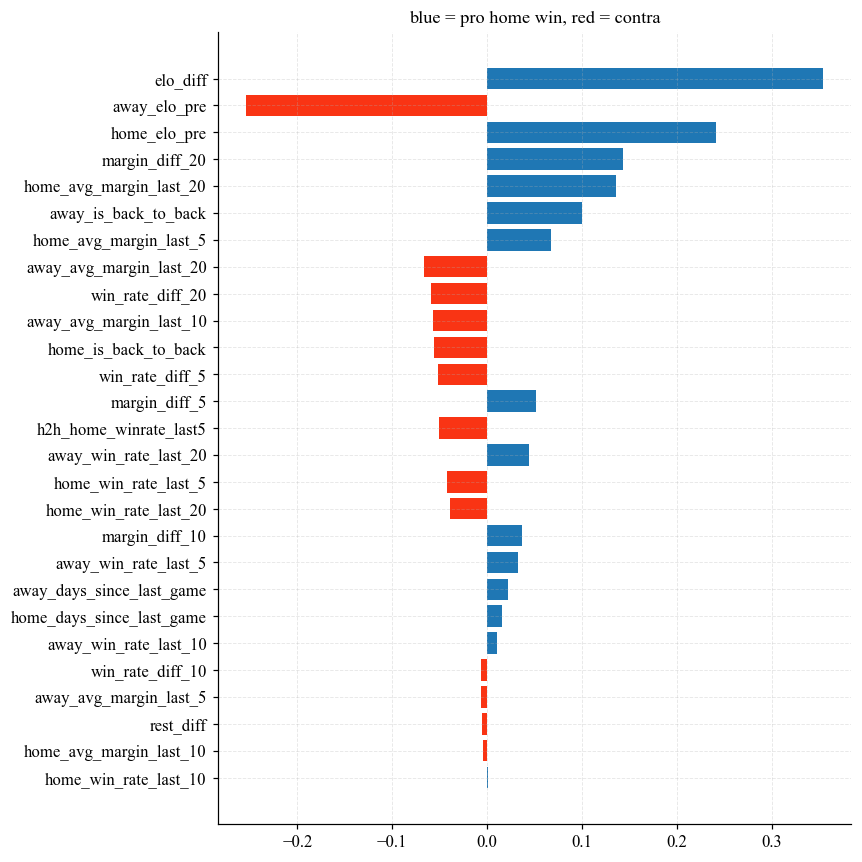

In [46]:
# which features have most impact?

coefs = pd.DataFrame({
    "feature": feature_cols,
    "coef": logreg.named_steps["classifier"].coef_[0],
}).assign(abs_coef=lambda d: d.coef.abs()).sort_values("abs_coef", ascending=False)



#print(coefs.feature, coefs.coef)


fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#1f77b4" if c > 0 else "#f93414" for c in coefs.coef]
ax.barh(coefs.feature, coefs.coef, color=colors)
ax.set_title("blue = pro home win, red = contra")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. XGBoost

Now we are moving from improvement to peak performance :D

Gradient-Boosted Trees better for more complex interactions and models. Its non directional only shows how usefull a feature is

In [62]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

results["XGBoost"] = {
    "accuracy": accuracy_score(y_test, xgb_pred),
    "log_loss": log_loss(y_test, xgb_proba),
    "brier":    brier_score_loss(y_test, xgb_proba),
    "auc":      roc_auc_score(y_test, xgb_proba),
}
results["XGBoost"]

{'accuracy': 0.6409395973154363,
 'log_loss': 0.6413576821280095,
 'brier': 0.22391071915626526,
 'auc': 0.6979195620753141}

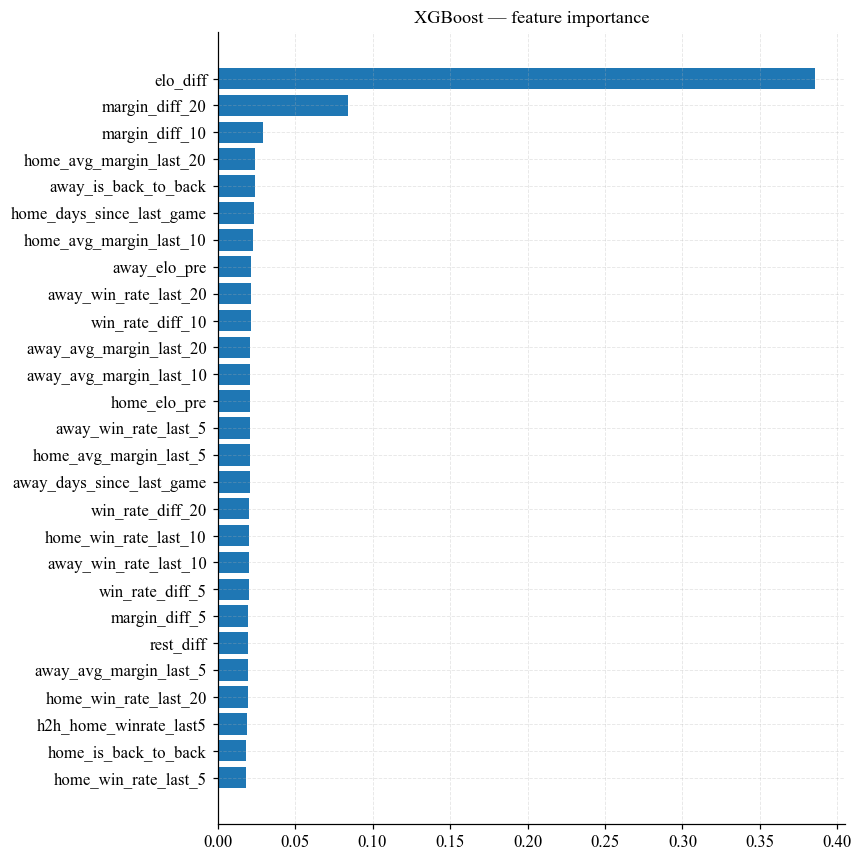

In [63]:
# XGBoost feature importance
DATA_PROCESSED = Path("..") / "data" / "processed"
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance.feature, importance.importance, color="#1f77b4")
ax.set_title("XGBoost — feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Comparing all models

**Metrics overview:**
- **Accuracy:** amount of correct predictions (0=bad, 1=perfect)
- **Log-Loss:** punishes confident for wrong predictions: eg. 55/45 and the predicition is wrong not that big of an issue. 99/1 and model is worng, thats a huge issue. The lower the better. 
- **Brier score** — mean squared error of the probabilities. The lower the better. 
- **AUC** — how well the model separates winners from losers (0.5=random, 1=perfect)

In [69]:
results_df = pd.DataFrame(results).T.round(3)
results_df

,accuracy,log_loss,brier,auc
Trivial,0.552,0.699,0.253,0.500
Logistic Regression,0.643,0.640,0.223,0.699
XGBoost,0.641,0.641,0.224,0.698


**Takeaway:** One can see a clear improvement between Trivial model and the other two. Logistic Regression and XGBoost are on similar levels of performance. Maybe XGBoost has not enought input variables and falls back to logistic regression.

## 9. Calibration

This is a sanity check wether my prediction is correct. The closer my values are to the diagonal the better my model.


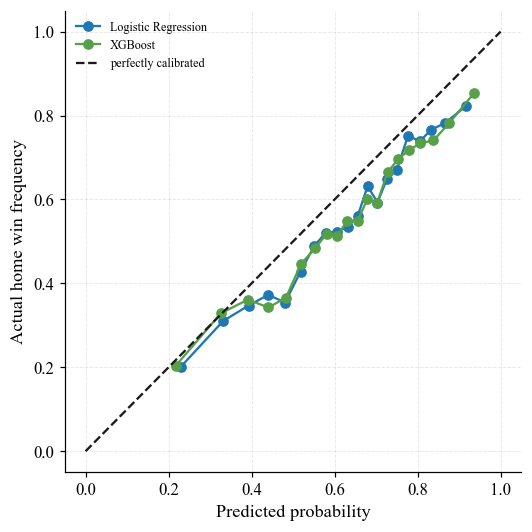

In [71]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, proba, color in [
    ("Logistic Regression", lr_proba, "#1f77b4"),
    ("XGBoost",             xgb_proba, "#57A048"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name, color=color)

ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual home win frequency")


ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** In this plot the model sits mostly **below** the diagonal. This means it is overconfident. This is something to work on from here on.

## 10. Confusion matrix

Where does the model make which mistakes?

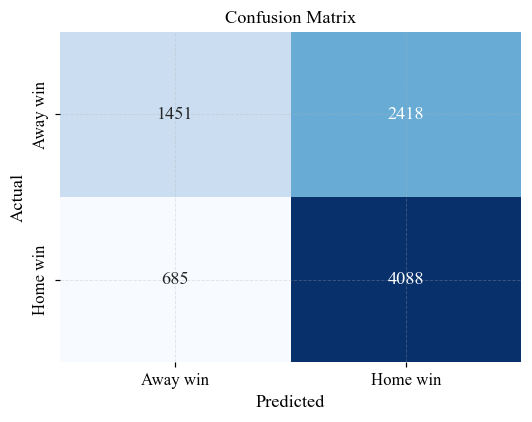

              precision    recall  f1-score   support

    Away win       0.68      0.38      0.48      3869
    Home win       0.63      0.86      0.72      4773

    accuracy                           0.64      8642
   macro avg       0.65      0.62      0.60      8642
weighted avg       0.65      0.64      0.62      8642



In [76]:
cm = confusion_matrix(y_test, xgb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Away win", "Home win"],
            yticklabels=["Away win", "Home win"], ax=ax)


ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, xgb_pred, target_names=["Away win", "Home win"]))

The model catches most home wins (86%), but barely an away win (38%). fq score away 0.48 ... rip. This is a clear bias! 

## 11. Save modell


In [77]:
import joblib
models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(xgb_model, models_dir / "xgb_baseline.pkl")
joblib.dump(logreg, models_dir / "logreg_baseline.pkl")
print("Models saved in models/")

Models saved in models/
